# Tasas de Interés del Sistema Bancario Peruano (2010-2026)> **Resumen:** Analicé 15 años de tasas de interés del sistema bancario peruano (fuente: BCRP) para entender cómo se transmite la política monetaria del Banco Central hacia los bancos comerciales, y cómo ha evolucionado el margen de ganancia bancario (spread) a lo largo del tiempo.**Stack técnico:** Python · Pandas · Matplotlib## DescripciónEste proyecto usa la [API pública de series estadísticas del BCRP](https://estadisticas.bcrp.gob.pe/estadisticas/series/) para descargar y analizar 4 series mensuales de tasas de interés en soles, desde enero 2010 hasta julio 2026:- **TAMN** — Tasa Activa promedio (lo que cobran los bancos por préstamos)- **TIPMN** — Tasa Pasiva promedio (lo que pagan los bancos por depósitos)- **Tasa Interbancaria** — tasa a la que los bancos se prestan entre sí- **Tasa de Referencia BCRP** — la tasa de política monetaria del Banco Central## Pipeline del Proyecto- **Extracción:** Descarga automatizada desde la API REST del BCRP (sin autenticación).- **Limpieza:** Parseo de fechas en español (ej. "Ene.2010"), unión de las 4 series por fecha, verificación de valores nulos.- **Feature engineering:** Cálculo del *Spread Bancario* (Tasa Activa − Tasa Pasiva), el indicador clave de rentabilidad del sistema bancario.- **Análisis exploratorio:** Evolución temporal, identificación de eventos macroeconómicos clave, correlación entre series.

## 1. Carga de datos

In [ ]:
import pandas as pdimport matplotlib.pyplot as pltimport matplotlib.dates as mdatesdf = pd.read_csv("data/tasas_bancarias_peru_2010_2026.csv", parse_dates=["fecha"])df.head()

       fecha  Tasa_Activa_TAMN  Tasa_Pasiva_TIPMN  Tasa_Interbancaria  Tasa_Referencia_BCRP  Spread_Bancario0 2010-01-01          19.97548           1.444581                 1.0                  1.25        18.5308991 2010-02-01          19.76036           1.391740                 1.2                  1.25        18.3686202 2010-03-01          19.48806           1.359680                 1.2                  1.25        18.1283803 2010-04-01          19.39367           1.297670                 1.2                  1.25        18.0960004 2010-05-01          19.17935           1.332580                 1.4                  1.50        17.846770

In [ ]:
print(f"Periodo: {df['fecha'].min().date()} a {df['fecha'].max().date()}")print(f"Total de registros: {len(df)}")print(f"Valores nulos totales: {df.isnull().sum().sum()}")

Periodo: 2010-01-01 a 2026-07-01Total de registros: 199Valores nulos totales: 0

## 2. Evolución de las tasas en el tiempoSe marcan 3 eventos macroeconómicos clave para contextualizar los movimientos: inicio de la pandemia, el inicio del ciclo de subida de tasas del BCRP para controlar la inflación, y el inicio de los recortes posteriores.

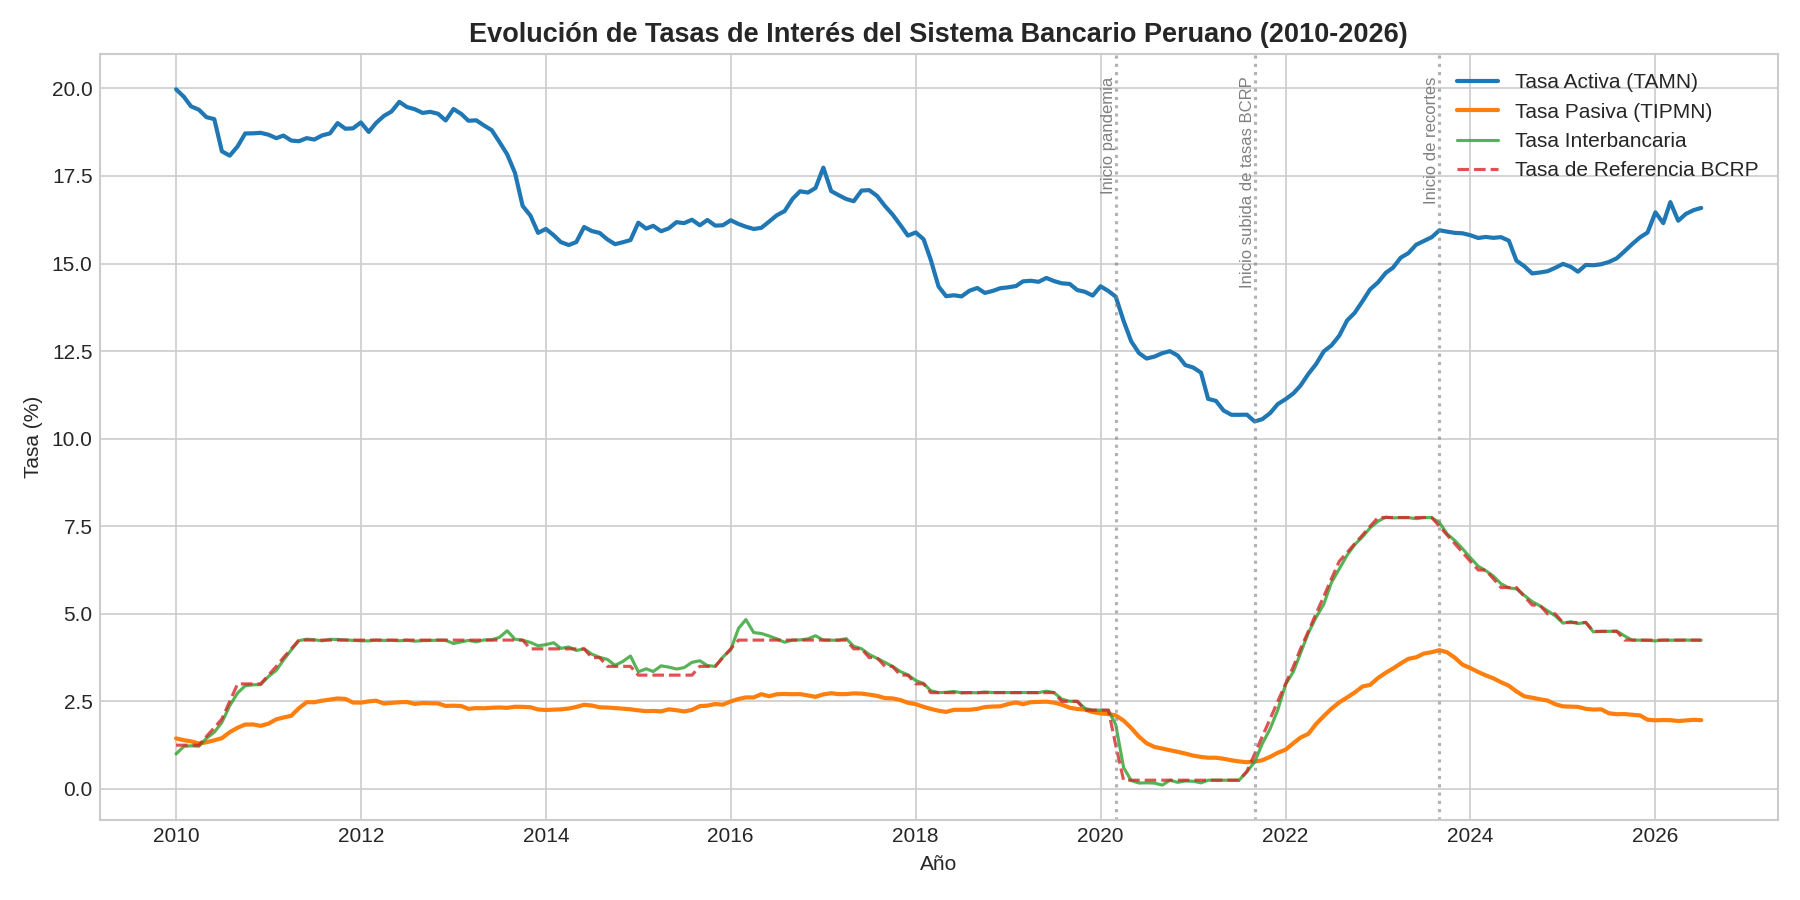

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))ax.plot(df["fecha"], df["Tasa_Activa_TAMN"], label="Tasa Activa (TAMN)", linewidth=2)ax.plot(df["fecha"], df["Tasa_Pasiva_TIPMN"], label="Tasa Pasiva (TIPMN)", linewidth=2)ax.plot(df["fecha"], df["Tasa_Interbancaria"], label="Tasa Interbancaria", linewidth=1.5, alpha=0.8)ax.plot(df["fecha"], df["Tasa_Referencia_BCRP"], label="Tasa de Referencia BCRP", linewidth=1.5, alpha=0.8, linestyle="--")eventos = {"2020-03-01": "Inicio pandemia", "2021-09-01": "Inicio subida de tasas BCRP", "2023-09-01": "Inicio de recortes"}for fecha_str, label in eventos.items():    fecha = pd.Timestamp(fecha_str)    ax.axvline(fecha, color="gray", linestyle=":", alpha=0.6)    ax.text(fecha, ax.get_ylim()[1]*0.97, label, rotation=90, fontsize=8, va="top", ha="right", color="gray")ax.set_title("Evolución de Tasas de Interés del Sistema Bancario Peruano (2010-2026)", fontsize=13, fontweight="bold")ax.set_ylabel("Tasa (%)")ax.set_xlabel("Año")ax.legend(loc="upper right")ax.xaxis.set_major_locator(mdates.YearLocator(2))ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))plt.tight_layout()plt.show()

**Lectura del gráfico:** la tasa interbancaria y la tasa de referencia del BCRP se mueven casi pegadas — es lógico, porque la interbancaria es el mecanismo directo de transmisión de la política monetaria. En cambio, la tasa activa (TAMN, lo que pagan los clientes de crédito) reacciona con más independencia: baja mucho menos durante la pandemia y sube con más fuerza después, lo que sugiere que los bancos trasladan las subidas más rápido que las bajadas.

## 3. Spread bancario: el margen de gananciaEl spread (TAMN − TIPMN) mide cuánto le queda al banco entre lo que cobra por préstamos y lo que paga por depósitos.

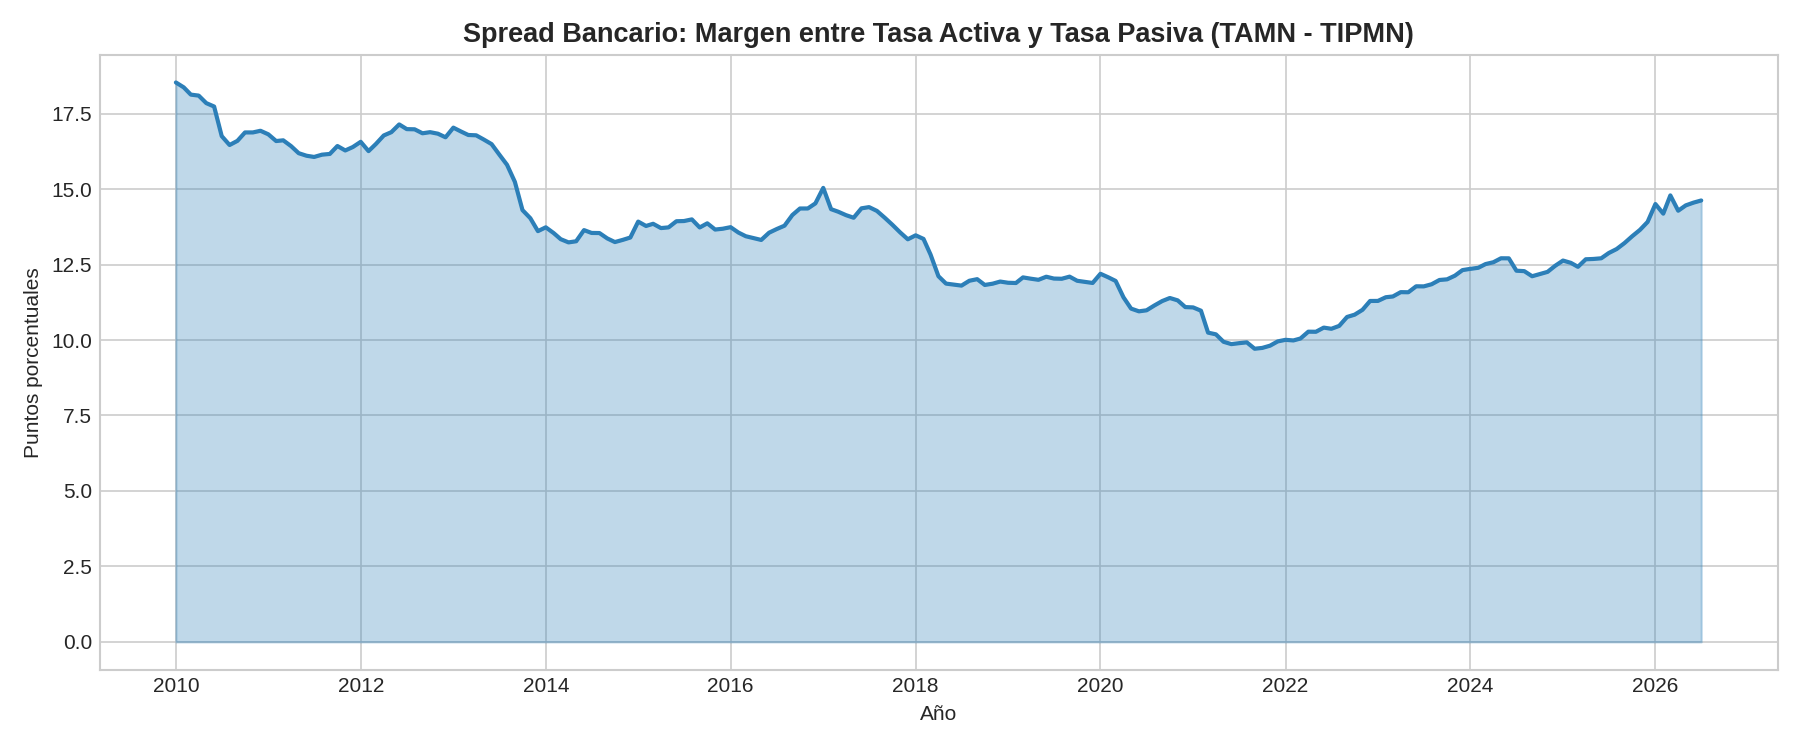

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))ax.fill_between(df["fecha"], df["Spread_Bancario"], color="#2c7fb8", alpha=0.3)ax.plot(df["fecha"], df["Spread_Bancario"], color="#2c7fb8", linewidth=2)ax.set_title("Spread Bancario: Margen entre Tasa Activa y Tasa Pasiva (TAMN - TIPMN)", fontsize=13, fontweight="bold")ax.set_ylabel("Puntos porcentuales")ax.set_xlabel("Año")ax.xaxis.set_major_locator(mdates.YearLocator(2))ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))plt.tight_layout()plt.show()

In [ ]:
spread_2010 = df[df["fecha"].dt.year == 2010]["Spread_Bancario"].mean()spread_2025 = df[df["fecha"].dt.year == 2025]["Spread_Bancario"].mean()print(f"Spread promedio 2010: {spread_2010:.2f} puntos")print(f"Spread promedio 2025: {spread_2025:.2f} puntos")print(f"Variación: {spread_2025 - spread_2010:.2f} puntos ({(spread_2025/spread_2010 - 1)*100:.1f}%)")

Spread promedio 2010: 17.43 puntosSpread promedio 2025: 12.98 puntosVariación: -4.45 puntos (-25.5%)

## 4. Correlación entre las series

In [ ]:
df[["Tasa_Activa_TAMN","Tasa_Pasiva_TIPMN","Tasa_Interbancaria","Tasa_Referencia_BCRP"]].corr().round(2)

                       Tasa_Activa_TAMN  Tasa_Pasiva_TIPMN  Tasa_Interbancaria  Tasa_Referencia_BCRPTasa_Activa_TAMN                   1.00               0.36                0.27                   0.27Tasa_Pasiva_TIPMN                  0.36               1.00                0.85                   0.84Tasa_Interbancaria                 0.27               0.85                1.00                   1.00Tasa_Referencia_BCRP               0.27               0.84                1.00                   1.00

## Conclusión del Proyecto- **La política monetaria se transmite casi de inmediato a la tasa interbancaria** (correlación de 1.00 con la tasa de referencia del BCRP), pero llega diluida y con rezago a la tasa activa que paga el cliente final (correlación de solo 0.27).- **La pandemia marcó el mínimo histórico:** la tasa interbancaria llegó a 0.11% en septiembre 2020, siguiendo al BCRP en su esfuerzo por reactivar la economía con crédito barato.- **El spread bancario se redujo 25% entre 2010 y 2025**, pasando de 17.4 a 13.0 puntos porcentuales en promedio — una señal de mayor competencia o presión regulatoria en el sistema financiero en los últimos 15 años.- **El spread es cíclico:** sube en momentos de incertidumbre (como el ciclo de subida de tasas 2022-2024) y se comprime en periodos de estabilidad.## Aplicación PrácticaEste tipo de análisis de series temporales financieras tiene aplicaciones directas en:- **Gestión de riesgo bancario:** monitorear el spread ayuda a anticipar presión sobre la rentabilidad del sector.- **Análisis de política monetaria:** entender qué tan rápido y completo es el traspaso ("pass-through") de las decisiones del Banco Central hacia el crédito real.- **Modelos predictivos:** esta serie limpia y estructurada es la base para modelos de forecasting de tasas (ARIMA, Prophet) o para features en modelos de scoring crediticio.